In [95]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [96]:
import os
import pandas as pd

print("Current working directory:")
print(os.getcwd())

print("\nFiles/Folders:")
print(os.listdir())

# Check the expected CSV path
file_path = os.path.join("data", "netflix_customer_churn.csv")

print("\nChecking file:")
print(file_path)

if os.path.exists(file_path):
    print("✅ CSV file found!")
    
    df = pd.read_csv(file_path)
    
    print("\n✅ Dataset loaded successfully!")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    
    print("\nFirst 5 records:")
    display(df.head())

else:
    print("❌ CSV file NOT found!")
    print("\nContents of current directory:")
    print(os.listdir())

Current working directory:
c:\Users\chetp\Downloads\ChetanPython\Netflix-Churn-Analysis\notebooks

Files/Folders:
['data', 'netflix_churn_analysis.ipynb']

Checking file:
data\netflix_customer_churn.csv
✅ CSV file found!

✅ Dataset loaded successfully!
Rows: 5000
Columns: 14

First 5 records:


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [97]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 5000
Number of Columns: 14


In [98]:
print("Columns in Dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, ".", column)

Columns in Dataset:

1 . customer_id
2 . age
3 . gender
4 . subscription_type
5 . watch_hours
6 . last_login_days
7 . region
8 . device
9 . monthly_fee
10 . churned
11 . payment_method
12 . number_of_profiles
13 . avg_watch_time_per_day
14 . favorite_genre


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 547.0

In [100]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [101]:
missing_values = df.isnull().sum()
print(missing_values)

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64


In [102]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_df

,Missing Values,Missing Percentage
customer_id,0,0.0
age,0,0.0
gender,0,0.0
subscription_type,0,0.0
watch_hours,0,0.0
last_login_days,0,0.0
region,0,0.0
device,0,0.0
monthly_fee,0,0.0
churned,0,0.0


In [103]:
print("Total Duplicate Rows:", df.duplicated().sum())

Total Duplicate Rows: 0


In [104]:
print("Duplicate Customer IDs:", df["customer_id"].duplicated().sum())

Duplicate Customer IDs: 0


In [105]:
categorical_columns = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column.upper())
    print("=" * 50)
    print(df[column].unique())


GENDER
<StringArray>
['Other', 'Female', 'Male']
Length: 3, dtype: str

SUBSCRIPTION_TYPE
<StringArray>
['Basic', 'Standard', 'Premium']
Length: 3, dtype: str

REGION
<StringArray>
['Africa', 'Europe', 'Asia', 'Oceania', 'South America', 'North America']
Length: 6, dtype: str

DEVICE
<StringArray>
['TV', 'Mobile', 'Laptop', 'Desktop', 'Tablet']
Length: 5, dtype: str

PAYMENT_METHOD
<StringArray>
['Gift Card', 'Crypto', 'Debit Card', 'PayPal', 'Credit Card']
Length: 5, dtype: str

FAVORITE_GENRE
<StringArray>
['Action', 'Sci-Fi', 'Drama', 'Horror', 'Romance', 'Comedy', 'Documentary']
Length: 7, dtype: str


In [106]:
for column in categorical_columns:
    print("\n", column.upper())
    print(df[column].value_counts())


 GENDER
gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

 SUBSCRIPTION_TYPE
subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

 REGION
region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

 DEVICE
device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

 PAYMENT_METHOD
payment_method
Debit Card     1030
PayPal         1026
Crypto          995
Gift Card       976
Credit Card     973
Name: count, dtype: int64

 FAVORITE_GENRE
favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64


In [107]:
print(df["churned"].value_counts())

churned
1    2515
0    2485
Name: count, dtype: int64


In [108]:
print(df["churned"].value_counts(normalize=True) * 100)

churned
1    50.3
0    49.7
Name: proportion, dtype: float64


In [109]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

summary

,Column,Data Type,Missing Values,Unique Values
customer_id,customer_id,str,0,5000
age,age,int64,0,53
gender,gender,str,0,3
subscription_type,subscription_type,str,0,3
watch_hours,watch_hours,float64,0,2343
last_login_days,last_login_days,int64,0,61
region,region,str,0,6
device,device,str,0,5
monthly_fee,monthly_fee,float64,0,3
churned,churned,int64,0,2


In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 547.0

In [111]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [112]:
df.duplicated().sum()

np.int64(0)

In [113]:
df["customer_id"].duplicated().sum()

np.int64(0)

In [114]:
df["churned"].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

In [115]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [116]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_df

,Missing Values,Missing Percentage
customer_id,0,0.0
age,0,0.0
gender,0,0.0
subscription_type,0,0.0
watch_hours,0,0.0
last_login_days,0,0.0
region,0,0.0
device,0,0.0
monthly_fee,0,0.0
churned,0,0.0


In [117]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [118]:
print("Duplicate Customer IDs:", df["customer_id"].duplicated().sum())

Duplicate Customer IDs: 0


In [119]:
print(df.dtypes)

customer_id                   str
age                         int64
gender                        str
subscription_type             str
watch_hours               float64
last_login_days             int64
region                        str
device                        str
monthly_fee               float64
churned                     int64
payment_method                str
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre                str
dtype: object


In [120]:
categorical_columns = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column.upper())
    print("=" * 50)
    print(df[column].value_counts())


GENDER
gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

SUBSCRIPTION_TYPE
subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

REGION
region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

DEVICE
device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

PAYMENT_METHOD
payment_method
Debit Card     1030
PayPal         1026
Crypto          995
Gift Card       976
Credit Card     973
Name: count, dtype: int64

FAVORITE_GENRE
favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64


In [121]:
print("Age range:")
print(df["age"].min(), "to", df["age"].max())

print("\nWatch hours range:")
print(df["watch_hours"].min(), "to", df["watch_hours"].max())

print("\nLast login days range:")
print(df["last_login_days"].min(), "to", df["last_login_days"].max())

print("\nMonthly fee range:")
print(df["monthly_fee"].min(), "to", df["monthly_fee"].max())

print("\nNumber of profiles range:")
print(df["number_of_profiles"].min(), "to", df["number_of_profiles"].max())

print("\nAverage watch time range:")
print(
    df["avg_watch_time_per_day"].min(),
    "to",
    df["avg_watch_time_per_day"].max()
)

Age range:
18 to 70

Watch hours range:
0.01 to 110.4

Last login days range:
0 to 60

Monthly fee range:
8.99 to 17.99

Number of profiles range:
1 to 5

Average watch time range:
0.0 to 98.42


In [122]:
print(df["churned"].unique())
print(df["churned"].value_counts())

[1 0]
churned
1    2515
0    2485
Name: count, dtype: int64


In [123]:
churn_percentage = df["churned"].value_counts(normalize=True) * 100

print(churn_percentage)

churned
1    50.3
0    49.7
Name: proportion, dtype: float64


In [124]:
print(
    "Customers with avg watch time > 10:",
    (df["avg_watch_time_per_day"] > 10).sum()
)

Customers with avg watch time > 10: 57


In [125]:
print(
    "Customers with avg watch time > 20:",
    (df["avg_watch_time_per_day"] > 20).sum()
)

Customers with avg watch time > 20: 14


In [126]:
df[df["avg_watch_time_per_day"] > 10][
    [
        "customer_id",
        "age",
        "watch_hours",
        "avg_watch_time_per_day",
        "churned"
    ]
].head(20)

,customer_id,age,watch_hours,avg_watch_time_per_day,churned
191,db2af8cb-89e8-4d68-b1b4-6620a2d5d041,68,52.22,10.44,0
275,10b94520-29d7-4845-917f-98fd0a3bf3e7,22,21.84,10.92,0
400,b563fad3-459d-424f-b754-d7e38a922faa,66,16.22,16.22,0
444,15d5126a-b913-491a-ba7c-73ceca42478c,20,21.21,21.21,0
478,801c7969-7d28-4e6b-8276-b4f92da9f3f6,36,22.91,22.91,0
495,e2716bd9-d203-499c-8788-c8a7f8b192a9,36,23.50,11.75,0
565,b72d9a7d-7c15-4521-8a90-479596bff39d,22,46.56,11.64,0
580,38948c93-2299-4dc1-9bcf-aadfdbde8079,44,18.92,18.92,0
647,c350d5a0-fef7-4281-b752-42162d72bd05,33,25.15,25.15,0
669,1ad47f3a-f860-4c98-81a5-8616344abafe,62,29.21,14.61,0


In [127]:
df[
    ["watch_hours", "avg_watch_time_per_day"]
].corr()

,watch_hours,avg_watch_time_per_day
watch_hours,1.000000,0.349742
avg_watch_time_per_day,0.349742,1.000000


In [128]:
data_quality = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

data_quality

,Column,Data Type,Missing Values,Unique Values
0,customer_id,str,0,5000
1,age,int64,0,53
2,gender,str,0,3
3,subscription_type,str,0,3
4,watch_hours,float64,0,2343
5,last_login_days,int64,0,61
6,region,str,0,6
7,device,str,0,5
8,monthly_fee,float64,0,3
9,churned,int64,0,2


In [129]:
df_raw = df.copy()

print("Original dataset shape:", df_raw.shape)

Original dataset shape: (5000, 14)


In [130]:
df_clean = df.copy()

In [131]:
duplicate_rows = df_clean.duplicated().sum()

print("Duplicate rows found:", duplicate_rows)

Duplicate rows found: 0


In [132]:
df_clean = df_clean.drop_duplicates()

In [133]:
print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (5000, 14)


In [134]:
duplicate_customers = df_clean["customer_id"].duplicated().sum()

print("Duplicate customer IDs:", duplicate_customers)

Duplicate customer IDs: 0


In [135]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [136]:
print(df_clean.columns.tolist())

['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']


In [137]:
text_columns = df_clean.select_dtypes(include="object").columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

C:\Users\chetp\AppData\Local\Temp\ipykernel_22264\3574154338.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df_clean.select_dtypes(include="object").columns


In [138]:
missing_after_cleaning = df_clean.isnull().sum()

print(missing_after_cleaning)

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64


In [139]:
print("Invalid ages:", ((df_clean["age"] < 18) | (df_clean["age"] > 100)).sum())

Invalid ages: 0


In [140]:
print("Invalid monthly fees:", (df_clean["monthly_fee"] <= 0).sum())

Invalid monthly fees: 0


In [141]:
print("Negative watch hours:", (df_clean["watch_hours"] < 0).sum())

Negative watch hours: 0


In [142]:
print("Negative last login days:", (df_clean["last_login_days"] < 0).sum())

Negative last login days: 0


In [143]:
print(
    "Invalid profile counts:",
    (
        (df_clean["number_of_profiles"] < 1) |
        (df_clean["number_of_profiles"] > 10)
    ).sum()
)

Invalid profile counts: 0


In [144]:
print("Invalid churn values:")
print(df_clean.loc[~df_clean["churned"].isin([0, 1]), "churned"])

Invalid churn values:
Series([], Name: churned, dtype: int64)


In [145]:
Q1 = df_clean["avg_watch_time_per_day"].quantile(0.25)
Q3 = df_clean["avg_watch_time_per_day"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 0.11
Q3: 0.72
IQR: 0.61
Lower Bound: -0.805
Upper Bound: 1.635


In [146]:
outliers = df_clean[
    (df_clean["avg_watch_time_per_day"] < lower_bound) |
    (df_clean["avg_watch_time_per_day"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 549


In [147]:
print("Original rows:", len(df_raw))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df_raw) - len(df_clean))

print("\nFinal shape:", df_clean.shape)

Original rows: 5000
Cleaned rows: 5000
Rows removed: 0

Final shape: (5000, 14)


Feature Engineering ⭐

In [148]:
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[17, 25, 35, 50, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-50",
        "51-65",
        "66+"
    ]
)

In [149]:
df_clean["age_group"].value_counts().sort_index()

age_group
18-25     801
26-35     949
36-50    1349
51-65    1433
66+       468
Name: count, dtype: int64

In [150]:
df_clean["activity_level"] = pd.cut(
    df_clean["watch_hours"],
    bins=[-1, 5, 15, 30, float("inf")],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [151]:
df_clean["activity_level"].value_counts()

activity_level
Medium       1876
Low          1770
High          989
Very High     365
Name: count, dtype: int64

In [152]:
df_clean["login_status"] = pd.cut(
    df_clean["last_login_days"],
    bins=[-1, 7, 30, 60, float("inf")],
    labels=[
        "Recently Active",
        "Active",
        "Inactive",
        "Highly Inactive"
    ]
)

In [153]:
df_clean["login_status"].value_counts()

login_status
Inactive           2469
Active             1881
Recently Active     650
Highly Inactive       0
Name: count, dtype: int64

In [154]:
df_clean["monthly_revenue"] = df_clean["monthly_fee"]

In [155]:
df_clean["annual_revenue"] = df_clean["monthly_fee"] * 12

In [156]:
df_clean["churn_status"] = df_clean["churned"].map({
    0: "Active",
    1: "Churned"
})

In [157]:
df_clean["churn_status"].value_counts()

churn_status
Churned    2515
Active     2485
Name: count, dtype: int64

In [158]:
df_clean.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,age_group,activity_level,login_status,monthly_revenue,annual_revenue,churn_status
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,51-65,Medium,Active,8.99,107.88,Churned
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,36-50,Low,Active,13.99,167.88,Churned
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,26-35,High,Active,13.99,167.88,Active
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,51-65,Low,Active,17.99,215.88,Churned
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,51-65,Low,Active,13.99,167.88,Churned


In [159]:
print("Final columns:")
print(df_clean.columns.tolist())

Final columns:
['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre', 'age_group', 'activity_level', 'login_status', 'monthly_revenue', 'annual_revenue', 'churn_status']


In [160]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   customer_id             5000 non-null   str     
 1   age                     5000 non-null   int64   
 2   gender                  5000 non-null   str     
 3   subscription_type       5000 non-null   str     
 4   watch_hours             5000 non-null   float64 
 5   last_login_days         5000 non-null   int64   
 6   region                  5000 non-null   str     
 7   device                  5000 non-null   str     
 8   monthly_fee             5000 non-null   float64 
 9   churned                 5000 non-null   int64   
 10  payment_method          5000 non-null   str     
 11  number_of_profiles      5000 non-null   int64   
 12  avg_watch_time_per_day  5000 non-null   float64 
 13  favorite_genre          5000 non-null   str     
 14  age_group               5000 non-nu

In [161]:
df_clean.shape

(5000, 20)

Connect to SQLite✅

In [162]:
import sqlite3

db_path = "../database/netflix_churn.db"

conn = sqlite3.connect(db_path)

print("✅ SQLite database connected successfully!")

✅ SQLite database connected successfully!


In [163]:
df_clean.to_sql(
    "netflix_customers",
    conn,
    if_exists="replace",
    index=False
)

print("✅ netflix_customers table created successfully!")

✅ netflix_customers table created successfully!


In [164]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,netflix_customers


In [165]:
df_sql = pd.read_sql_query(
    "SELECT * FROM netflix_customers",
    conn
)

print("Rows:", df_sql.shape[0])
print("Columns:", df_sql.shape[1])

Rows: 5000
Columns: 20


In [166]:
df_sql.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,age_group,activity_level,login_status,monthly_revenue,annual_revenue,churn_status
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,51-65,Medium,Active,8.99,107.88,Churned
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,36-50,Low,Active,13.99,167.88,Churned
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,26-35,High,Active,13.99,167.88,Active
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,51-65,Low,Active,17.99,215.88,Churned
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,51-65,Low,Active,13.99,167.88,Churned


In [167]:
query = """
SELECT *
FROM netflix_customers
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,age_group,activity_level,login_status,monthly_revenue,annual_revenue,churn_status
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,51-65,Medium,Active,8.99,107.88,Churned
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,36-50,Low,Active,13.99,167.88,Churned
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,26-35,High,Active,13.99,167.88,Active
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,51-65,Low,Active,17.99,215.88,Churned
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,51-65,Low,Active,13.99,167.88,Churned
5,d8079475-5be7-47e9-8782-ceb7ff61395e,58,Female,Standard,13.80,26,Oceania,Mobile,13.99,0,Debit Card,3,0.51,Action,51-65,Medium,Active,13.99,167.88,Active
6,8e63450a-13d6-4e83-bbb5-6aebde9152cb,48,Other,Basic,13.83,20,Asia,TV,8.99,0,Gift Card,5,0.66,Romance,36-50,Medium,Active,8.99,107.88,Active
7,02387681-8c42-462a-807a-de0168c73b38,51,Male,Basic,14.30,56,Europe,Mobile,8.99,1,Gift Card,1,0.25,Action,51-65,Medium,Inactive,8.99,107.88,Churned
8,0bcaad0c-545c-4ee1-85a6-75e165f39361,45,Other,Basic,9.98,10,Asia,Mobile,8.99,0,PayPal,3,0.91,Romance,36-50,Medium,Active,8.99,107.88,Active
9,eae6439e-8cdf-4258-ab49-c493925b927a,32,Other,Premium,2.22,34,Europe,TV,17.99,1,Debit Card,1,0.06,Drama,26-35,Low,Inactive,17.99,215.88,Churned


In [168]:
query = """
SELECT COUNT(*) AS total_customers
FROM netflix_customers;
"""

pd.read_sql_query(query, conn)

,total_customers
0,5000


In [169]:
query = """
SELECT
    churn_status,
    COUNT(*) AS customer_count
FROM netflix_customers
GROUP BY churn_status;
"""

pd.read_sql_query(query, conn)

,churn_status,customer_count
0,Active,2485
1,Churned,2515


In [170]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers;
"""

pd.read_sql_query(query, conn)

,total_customers,churned_customers,churn_rate
0,5000,2515,50.3


Churn by subscription type ⭐

This is an important business question:

Which Netflix subscription has the highest churn?

In [171]:
query = """
SELECT
    subscription_type,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY subscription_type
ORDER BY churn_rate DESC;
"""

churn_by_subscription = pd.read_sql_query(query, conn)

churn_by_subscription

,subscription_type,total_customers,churned_customers,churn_rate
0,Basic,1661,1027,61.83
1,Standard,1646,748,45.44
2,Premium,1693,740,43.71


Churn by region

In [172]:
query = """
SELECT
    region,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY region
ORDER BY churn_rate DESC;
"""

churn_by_region = pd.read_sql_query(query, conn)

churn_by_region

,region,total_customers,churned_customers,churn_rate
0,Europe,867,448,51.67
1,South America,873,449,51.43
2,Asia,841,426,50.65
3,Oceania,765,383,50.07
4,North America,851,421,49.47
5,Africa,803,388,48.32


Churn by device

In [173]:
query = """
SELECT
    device,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY device
ORDER BY churn_rate DESC;
"""

churn_by_device = pd.read_sql_query(query, conn)

churn_by_device

,device,total_customers,churned_customers,churn_rate
0,Laptop,1006,521,51.79
1,Mobile,1004,507,50.50
2,Tablet,1048,524,50.00
3,TV,993,496,49.95
4,Desktop,949,467,49.21


Churn by payment method

In [174]:
query = """
SELECT
    payment_method,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY payment_method
ORDER BY churn_rate DESC;
"""

churn_by_payment = pd.read_sql_query(query, conn)

churn_by_payment

,payment_method,total_customers,churned_customers,churn_rate
0,Crypto,995,594,59.70
1,Gift Card,976,564,57.79
2,PayPal,1026,483,47.08
3,Debit Card,1030,450,43.69
4,Credit Card,973,424,43.58


Churn by gender

In [175]:
query = """
SELECT
    gender,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY gender
ORDER BY churn_rate DESC;
"""

churn_by_gender = pd.read_sql_query(query, conn)

churn_by_gender

,gender,total_customers,churned_customers,churn_rate
0,Female,1711,874,51.08
1,Male,1654,827,50.00
2,Other,1635,814,49.79


Churn by age group ⭐

In [176]:
query = """
SELECT
    age_group,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY age_group
ORDER BY churn_rate DESC;
"""

churn_by_age = pd.read_sql_query(query, conn)

churn_by_age

,age_group,total_customers,churned_customers,churn_rate
0,18-25,801,406,50.69
1,26-35,949,478,50.37
2,51-65,1433,720,50.24
3,66+,468,235,50.21
4,36-50,1349,676,50.11


Churn by activity level ⭐⭐⭐

In [177]:
query = """
SELECT
    activity_level,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY activity_level
ORDER BY churn_rate DESC;
"""

churn_by_activity = pd.read_sql_query(query, conn)

churn_by_activity

,activity_level,total_customers,churned_customers,churn_rate
0,Low,1770,1486,83.95
1,Medium,1876,826,44.03
2,High,989,200,20.22
3,Very High,365,3,0.82


Churn by login status

In [178]:
query = """
SELECT
    login_status,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY login_status
ORDER BY churn_rate DESC;
"""

churn_by_login = pd.read_sql_query(query, conn)

churn_by_login

,login_status,total_customers,churned_customers,churn_rate
0,Inactive,2469,1854,75.09
1,Active,1881,574,30.52
2,Recently Active,650,87,13.38


STEP 6 — Advanced SQL + Revenue Analysis

We'll calculate things such as:

💰 Total monthly revenue
💰 Annual revenue
💸 Revenue lost from churned customers
📊 Revenue by subscription
🌎 Revenue by region
📱 Revenue by device
🎬 Most popular genres
👥 Customer segmentation
🔎 High-risk churn customers
🏆 Top customer segments
📈 SQL queries using CASE, subqueries, CTEs, and window functions

In [179]:
query = """
SELECT
    ROUND(SUM(monthly_fee), 2) AS total_monthly_revenue
FROM netflix_customers;
"""

total_revenue = pd.read_sql_query(query, conn)

total_revenue

,total_monthly_revenue
0,68417.0


In [180]:
query = """
SELECT
    ROUND(SUM(monthly_fee) * 12, 2) AS total_annual_revenue
FROM netflix_customers;
"""

annual_revenue = pd.read_sql_query(query, conn)

annual_revenue

,total_annual_revenue
0,821004.0


In [181]:
query = """
SELECT
    churn_status,
    COUNT(*) AS customers,
    ROUND(SUM(monthly_fee), 2) AS monthly_revenue,
    ROUND(SUM(monthly_fee) * 12, 2) AS annual_revenue
FROM netflix_customers
GROUP BY churn_status;
"""

revenue_by_churn = pd.read_sql_query(query, conn)

revenue_by_churn

,churn_status,customers,monthly_revenue,annual_revenue
0,Active,2485,35407.15,424885.8
1,Churned,2515,33009.85,396118.2


In [182]:
query = """
SELECT
    ROUND(SUM(monthly_fee), 2) AS monthly_revenue_at_risk
FROM netflix_customers
WHERE churned = 1;
"""

revenue_at_risk = pd.read_sql_query(query, conn)

revenue_at_risk

,monthly_revenue_at_risk
0,33009.85


In [183]:
query = """
SELECT
    ROUND(SUM(monthly_fee) * 12, 2) AS annual_revenue_at_risk
FROM netflix_customers
WHERE churned = 1;
"""

annual_revenue_at_risk = pd.read_sql_query(query, conn)

annual_revenue_at_risk

,annual_revenue_at_risk
0,396118.2


In [184]:
query = """
SELECT
    subscription_type,
    COUNT(*) AS customers,
    ROUND(SUM(monthly_fee), 2) AS monthly_revenue,
    ROUND(AVG(monthly_fee), 2) AS average_monthly_fee,
    ROUND(SUM(monthly_fee) * 12, 2) AS annual_revenue
FROM netflix_customers
GROUP BY subscription_type
ORDER BY monthly_revenue DESC;
"""

revenue_by_subscription = pd.read_sql_query(query, conn)

revenue_by_subscription

,subscription_type,customers,monthly_revenue,average_monthly_fee,annual_revenue
0,Premium,1693,30457.07,17.99,365484.84
1,Standard,1646,23027.54,13.99,276330.48
2,Basic,1661,14932.39,8.99,179188.68


In [185]:
query = """
SELECT
    subscription_type,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(SUM(monthly_fee), 2) AS total_monthly_revenue,
    ROUND(SUM(CASE WHEN churned = 1 THEN monthly_fee ELSE 0 END), 2)
        AS monthly_revenue_at_risk
FROM netflix_customers
GROUP BY subscription_type
ORDER BY monthly_revenue_at_risk DESC;
"""

subscription_business = pd.read_sql_query(query, conn)

subscription_business

,subscription_type,total_customers,churned_customers,churn_rate,total_monthly_revenue,monthly_revenue_at_risk
0,Premium,1693,740,43.71,30457.07,13312.60
1,Standard,1646,748,45.44,23027.54,10464.52
2,Basic,1661,1027,61.83,14932.39,9232.73


In [186]:
query = """
SELECT
    region,
    COUNT(*) AS customers,
    ROUND(SUM(monthly_fee), 2) AS monthly_revenue,
    ROUND(AVG(monthly_fee), 2) AS average_monthly_fee,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY region
ORDER BY monthly_revenue DESC;
"""

region_business = pd.read_sql_query(query, conn)

region_business

,region,customers,monthly_revenue,average_monthly_fee,churned_customers,churn_rate
0,South America,873,11921.27,13.66,449,51.43
1,Europe,867,11865.33,13.69,448,51.67
2,North America,851,11607.49,13.64,421,49.47
3,Asia,841,11436.59,13.60,426,50.65
4,Africa,803,11001.97,13.70,388,48.32
5,Oceania,765,10584.35,13.84,383,50.07


In [187]:
query = """
SELECT
    device,
    COUNT(*) AS customers,
    ROUND(SUM(monthly_fee), 2) AS monthly_revenue,
    ROUND(AVG(monthly_fee), 2) AS average_monthly_fee,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY device
ORDER BY monthly_revenue DESC;
"""

device_business = pd.read_sql_query(query, conn)

device_business

,device,customers,monthly_revenue,average_monthly_fee,churned_customers,churn_rate
0,Tablet,1048,14288.52,13.63,524,50.00
1,Laptop,1006,13754.94,13.67,521,51.79
2,Mobile,1004,13663.96,13.61,507,50.50
3,TV,993,13499.07,13.59,496,49.95
4,Desktop,949,13210.51,13.92,467,49.21


In [188]:
query = """
SELECT
    payment_method,
    COUNT(*) AS customers,
    ROUND(SUM(monthly_fee), 2) AS monthly_revenue,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY payment_method
ORDER BY monthly_revenue DESC;
"""

payment_business = pd.read_sql_query(query, conn)

payment_business

,payment_method,customers,monthly_revenue,churned_customers,churn_rate
0,Debit Card,1030,14139.70,450,43.69
1,Crypto,995,13848.05,594,59.70
2,PayPal,1026,13816.74,483,47.08
3,Gift Card,976,13429.24,564,57.79
4,Credit Card,973,13183.27,424,43.58


In [189]:
query = """
SELECT
    favorite_genre,
    COUNT(*) AS customers
FROM netflix_customers
GROUP BY favorite_genre
ORDER BY customers DESC;
"""

genre_popularity = pd.read_sql_query(query, conn)

genre_popularity

,favorite_genre,customers
0,Drama,731
1,Documentary,729
2,Romance,725
3,Sci-Fi,720
4,Horror,713
5,Action,697
6,Comedy,685


In [190]:
query = """
SELECT
    favorite_genre,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM netflix_customers
GROUP BY favorite_genre
ORDER BY churn_rate DESC;
"""

genre_churn = pd.read_sql_query(query, conn)

genre_churn

,favorite_genre,total_customers,churned_customers,churn_rate
0,Action,697,365,52.37
1,Drama,731,382,52.26
2,Horror,713,367,51.47
3,Documentary,729,370,50.75
4,Comedy,685,342,49.93
5,Romance,725,350,48.28
6,Sci-Fi,720,339,47.08


In [191]:
query = """
SELECT
    churn_status,
    COUNT(*) AS customers,
    ROUND(AVG(watch_hours), 2) AS avg_watch_hours,
    ROUND(AVG(avg_watch_time_per_day), 2) AS avg_daily_watch_time
FROM netflix_customers
GROUP BY churn_status;
"""

engagement_churn = pd.read_sql_query(query, conn)

engagement_churn

,churn_status,customers,avg_watch_hours,avg_daily_watch_time
0,Active,2485,17.45,1.59
1,Churned,2515,5.92,0.16


In [192]:
query = """
SELECT
    churn_status,
    COUNT(*) AS customers,
    ROUND(AVG(last_login_days), 2) AS avg_days_since_login
FROM netflix_customers
GROUP BY churn_status;
"""

login_churn = pd.read_sql_query(query, conn)

login_churn

,churn_status,customers,avg_days_since_login
0,Active,2485,21.77
1,Churned,2515,38.31


In [193]:
query = """
SELECT
    activity_level,
    COUNT(*) AS customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(AVG(monthly_fee), 2) AS avg_monthly_fee
FROM netflix_customers
GROUP BY activity_level
ORDER BY churn_rate DESC;
"""

activity_analysis = pd.read_sql_query(query, conn)

activity_analysis

,activity_level,customers,churned_customers,churn_rate,avg_monthly_fee
0,Low,1770,1486,83.95,13.74
1,Medium,1876,826,44.03,13.55
2,High,989,200,20.22,13.81
3,Very High,365,3,0.82,13.76


In [194]:
query = """
SELECT
    customer_id,
    age,
    subscription_type,
    watch_hours,
    last_login_days,
    monthly_fee,
    region,
    device,
    favorite_genre,
    churn_status
FROM netflix_customers
WHERE churned = 1
  AND last_login_days >= 30
ORDER BY monthly_fee DESC;
"""

high_risk_customers = pd.read_sql_query(query, conn)

high_risk_customers.head(20)

,customer_id,age,subscription_type,watch_hours,last_login_days,monthly_fee,region,device,favorite_genre,churn_status
0,eae6439e-8cdf-4258-ab49-c493925b927a,32,Premium,2.22,34,17.99,Europe,TV,Drama,Churned
1,a8c8dcff-92d3-4a79-849d-42c6e6bbc7bc,70,Premium,7.97,57,17.99,Europe,Laptop,Drama,Churned
2,8c2d377b-f6ec-44b5-ae08-3660c4358a93,30,Premium,1.37,55,17.99,North America,Mobile,Horror,Churned
3,e62d9bc8-dab9-42e0-b6b2-e8d076fe843b,23,Premium,13.31,34,17.99,Africa,Mobile,Romance,Churned
4,c8648f0f-0b92-4445-a3a7-5c48711cbc07,57,Premium,0.97,32,17.99,South America,Mobile,Comedy,Churned
5,cdf4012d-14b0-41d5-ab40-cc6627fe1e3b,34,Premium,12.82,45,17.99,North America,Mobile,Romance,Churned
6,a2eab47c-dc4c-427f-88f8-755051b303fb,51,Premium,3.70,37,17.99,South America,Mobile,Horror,Churned
7,da57899f-77b4-4b23-bcab-700db438f6d1,43,Premium,2.50,33,17.99,Europe,TV,Action,Churned
8,361aff57-8a5f-4229-b4f5-f52544178dc7,63,Premium,6.97,31,17.99,North America,Tablet,Romance,Churned
9,005b6afc-cff9-432f-ae0e-265d9acb5a59,63,Premium,3.39,57,17.99,South America,Mobile,Sci-Fi,Churned


In [195]:
query = """
SELECT
    customer_id,
    subscription_type,
    region,
    device,
    monthly_fee,
    ROUND(monthly_fee * 12, 2) AS annual_revenue_at_risk,
    last_login_days,
    watch_hours
FROM netflix_customers
WHERE churned = 1
ORDER BY annual_revenue_at_risk DESC
LIMIT 20;
"""

top_revenue_risk = pd.read_sql_query(query, conn)

top_revenue_risk

,customer_id,subscription_type,region,device,monthly_fee,annual_revenue_at_risk,last_login_days,watch_hours
0,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,Premium,Oceania,TV,17.99,215.88,12,4.51
1,eae6439e-8cdf-4258-ab49-c493925b927a,Premium,Europe,TV,17.99,215.88,34,2.22
2,bf48551e-a8e6-4fd9-bb32-3f798ed84680,Premium,Europe,Tablet,17.99,215.88,13,1.25
3,a8c8dcff-92d3-4a79-849d-42c6e6bbc7bc,Premium,Europe,Laptop,17.99,215.88,57,7.97
4,8c2d377b-f6ec-44b5-ae08-3660c4358a93,Premium,North America,Mobile,17.99,215.88,55,1.37
5,e62d9bc8-dab9-42e0-b6b2-e8d076fe843b,Premium,Africa,Mobile,17.99,215.88,34,13.31
6,c8648f0f-0b92-4445-a3a7-5c48711cbc07,Premium,South America,Mobile,17.99,215.88,32,0.97
7,cdf4012d-14b0-41d5-ab40-cc6627fe1e3b,Premium,North America,Mobile,17.99,215.88,45,12.82
8,20529e32-d3e7-4cfc-8210-b6468cdbe2a4,Premium,Europe,Tablet,17.99,215.88,25,3.86
9,a2eab47c-dc4c-427f-88f8-755051b303fb,Premium,South America,Mobile,17.99,215.88,37,3.70


In [196]:
query = """
SELECT
    customer_id,
    subscription_type,
    monthly_fee,
    CASE
        WHEN monthly_fee >= 17 THEN 'High Value'
        WHEN monthly_fee >= 13 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS customer_value
FROM netflix_customers
LIMIT 20;
"""

customer_value = pd.read_sql_query(query, conn)

customer_value

,customer_id,subscription_type,monthly_fee,customer_value
0,a9b75100-82a8-427a-a208-72f24052884a,Basic,8.99,Low Value
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,Standard,13.99,Medium Value
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,Standard,13.99,Medium Value
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,Premium,17.99,High Value
4,4e265c34-103a-4dbb-9553-76c9aa47e946,Standard,13.99,Medium Value
5,d8079475-5be7-47e9-8782-ceb7ff61395e,Standard,13.99,Medium Value
6,8e63450a-13d6-4e83-bbb5-6aebde9152cb,Basic,8.99,Low Value
7,02387681-8c42-462a-807a-de0168c73b38,Basic,8.99,Low Value
8,0bcaad0c-545c-4ee1-85a6-75e165f39361,Basic,8.99,Low Value
9,eae6439e-8cdf-4258-ab49-c493925b927a,Premium,17.99,High Value


In [197]:
query = """
SELECT
    CASE
        WHEN monthly_fee >= 17 THEN 'High Value'
        WHEN monthly_fee >= 13 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS customer_value,
    COUNT(*) AS customers,
    SUM(churned) AS churned_customers,
    ROUND(
        SUM(churned) * 100.0 / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(SUM(monthly_fee), 2) AS monthly_revenue
FROM netflix_customers
GROUP BY customer_value
ORDER BY churn_rate DESC;
"""

customer_value_analysis = pd.read_sql_query(query, conn)

customer_value_analysis

,customer_value,customers,churned_customers,churn_rate,monthly_revenue
0,Low Value,1661,1027,61.83,14932.39
1,Medium Value,1646,748,45.44,23027.54
2,High Value,1693,740,43.71,30457.07


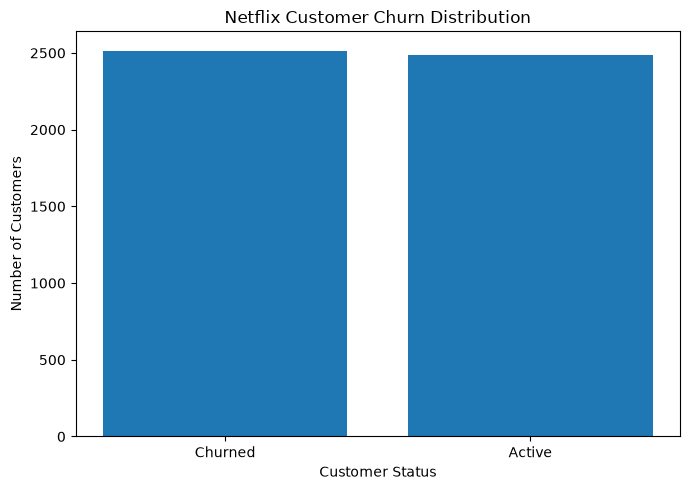

In [198]:
churn_counts = df_clean["churn_status"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Netflix Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

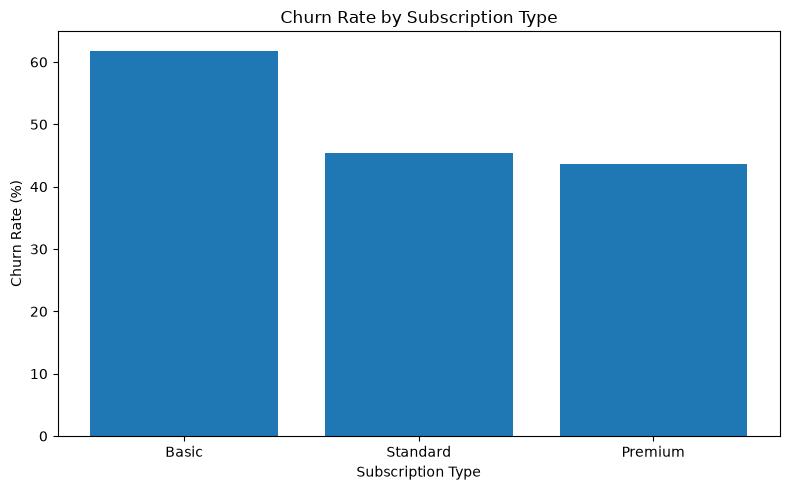

In [199]:
subscription_churn = (
    df_clean.groupby("subscription_type")["churned"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    subscription_churn.index,
    subscription_churn.values
)

plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

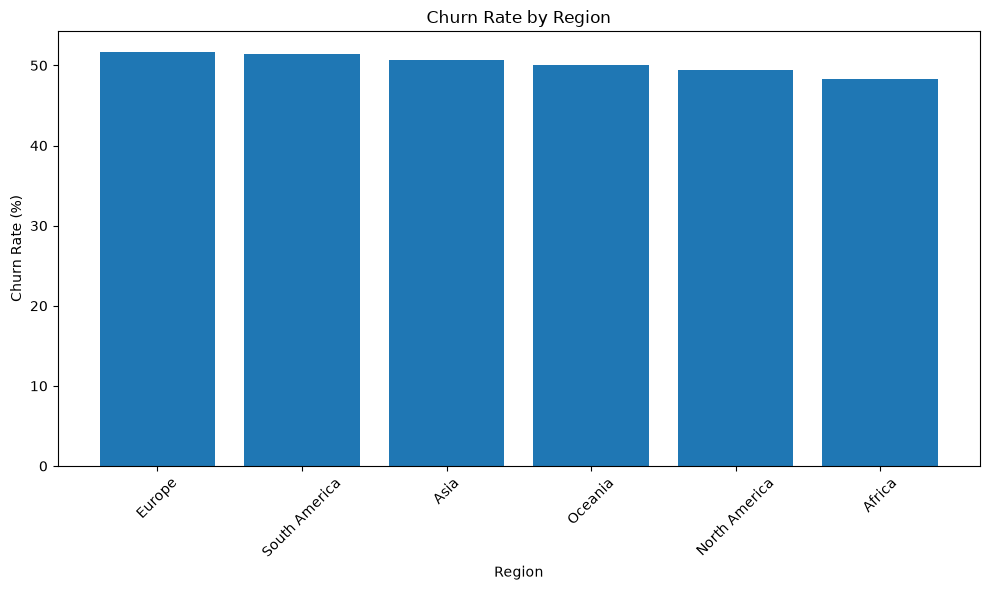

In [200]:
region_churn = (
    df_clean.groupby("region")["churned"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    region_churn.index,
    region_churn.values
)

plt.title("Churn Rate by Region")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

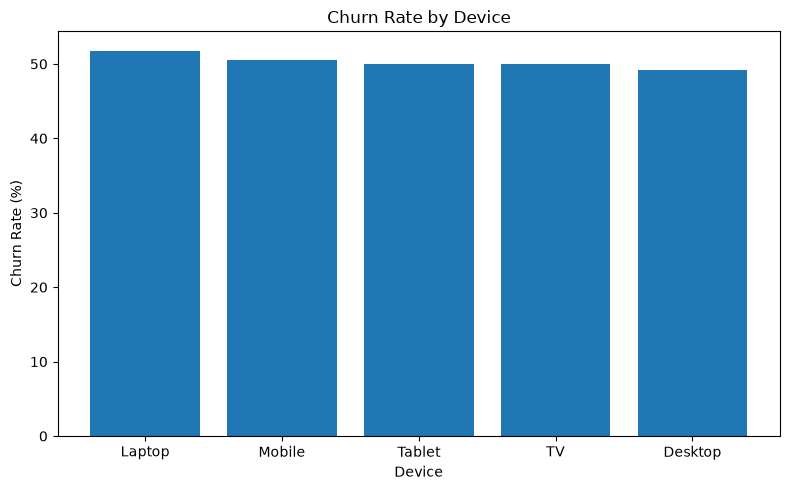

In [201]:
device_churn = (
    df_clean.groupby("device")["churned"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    device_churn.index,
    device_churn.values
)

plt.title("Churn Rate by Device")
plt.xlabel("Device")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

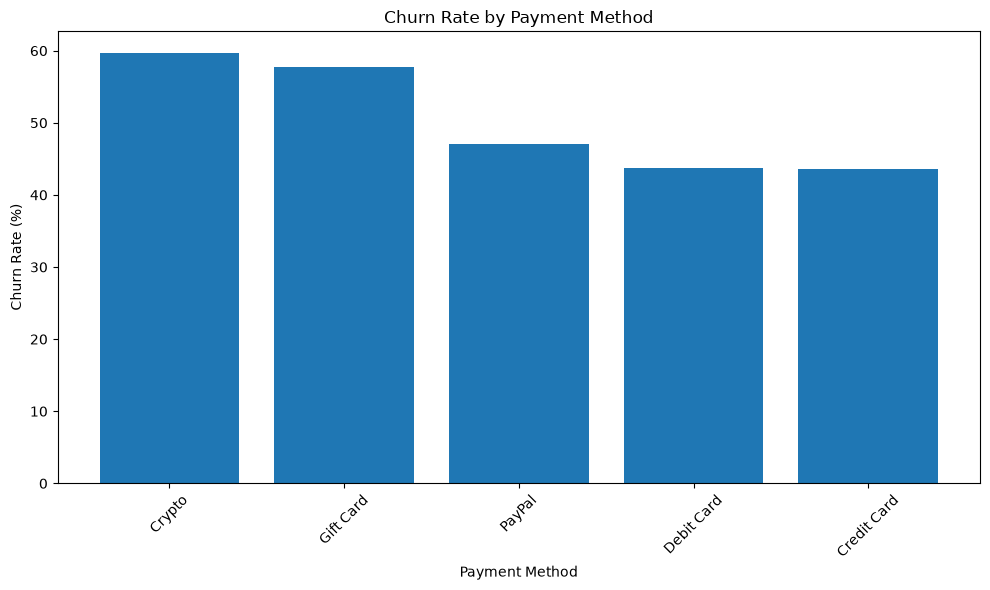

In [202]:
payment_churn = (
    df_clean.groupby("payment_method")["churned"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    payment_churn.index,
    payment_churn.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

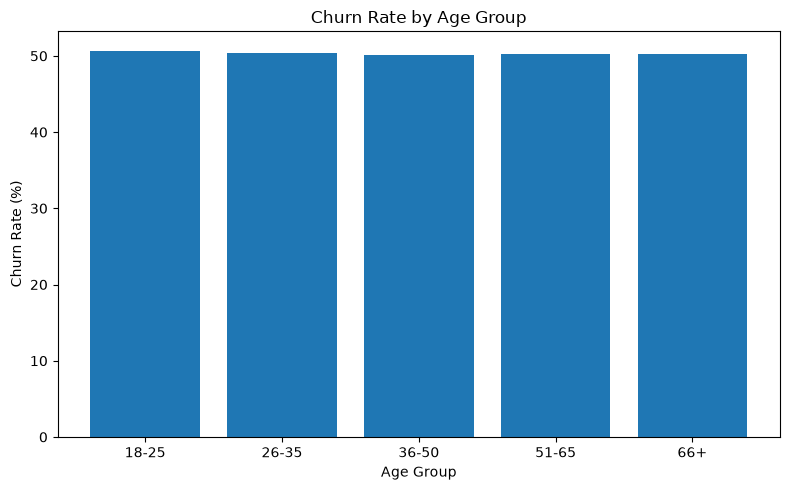

In [203]:
age_churn = (
    df_clean.groupby("age_group", observed=True)["churned"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))

plt.bar(
    age_churn.index.astype(str),
    age_churn.values
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

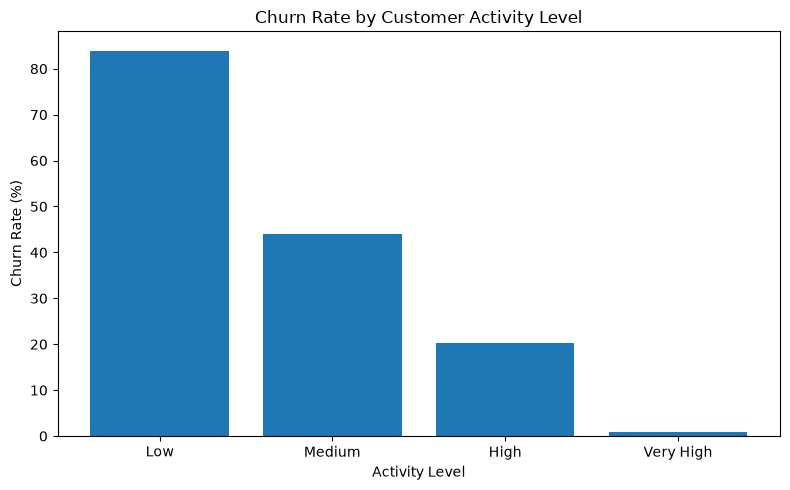

In [204]:
activity_churn = (
    df_clean.groupby("activity_level", observed=True)["churned"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))

plt.bar(
    activity_churn.index.astype(str),
    activity_churn.values
)

plt.title("Churn Rate by Customer Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

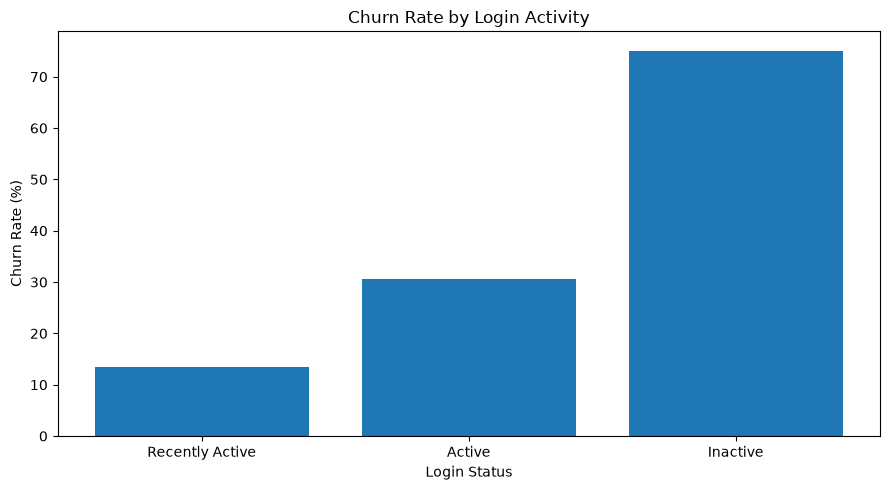

In [205]:
login_churn = (
    df_clean.groupby("login_status", observed=True)["churned"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

plt.bar(
    login_churn.index.astype(str),
    login_churn.values
)

plt.title("Churn Rate by Login Activity")
plt.xlabel("Login Status")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

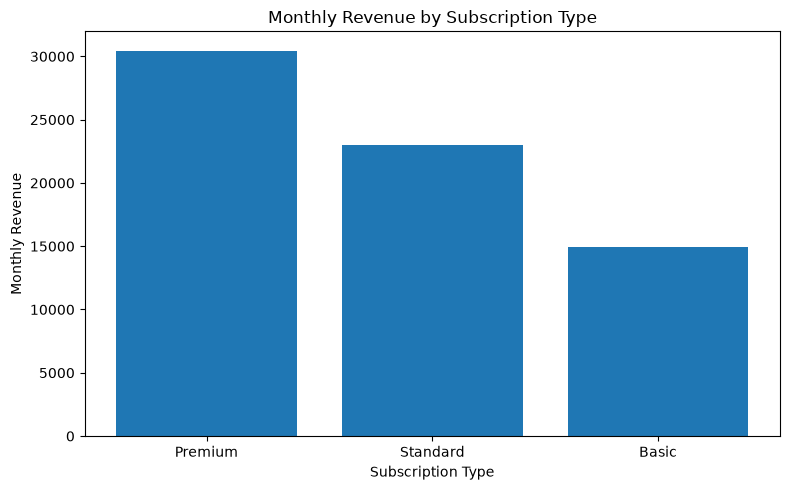

In [206]:
revenue_subscription = (
    df_clean.groupby("subscription_type")["monthly_fee"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    revenue_subscription.index,
    revenue_subscription.values
)

plt.title("Monthly Revenue by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Monthly Revenue")

plt.tight_layout()
plt.show()

In [207]:
revenue_at_risk = (
    df_clean.loc[df_clean["churned"] == 1, "monthly_fee"]
    .sum()
)

print("Monthly Revenue at Risk: ₹", round(revenue_at_risk, 2))

print(
    "Annualized Revenue at Risk: ₹",
    round(revenue_at_risk * 12, 2)
)

Monthly Revenue at Risk: ₹ 33009.85
Annualized Revenue at Risk: ₹ 396118.2


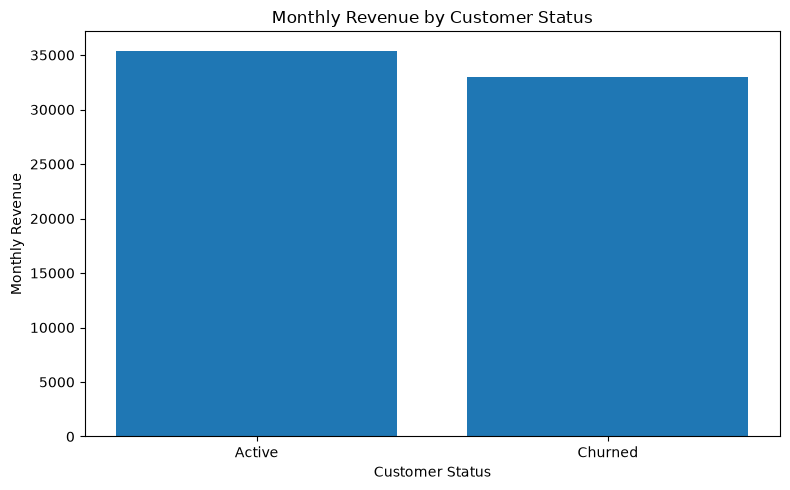

In [208]:
revenue_status = (
    df_clean.groupby("churn_status")["monthly_fee"]
    .sum()
)

plt.figure(figsize=(8, 5))

plt.bar(
    revenue_status.index,
    revenue_status.values
)

plt.title("Monthly Revenue by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Revenue")

plt.tight_layout()
plt.show()

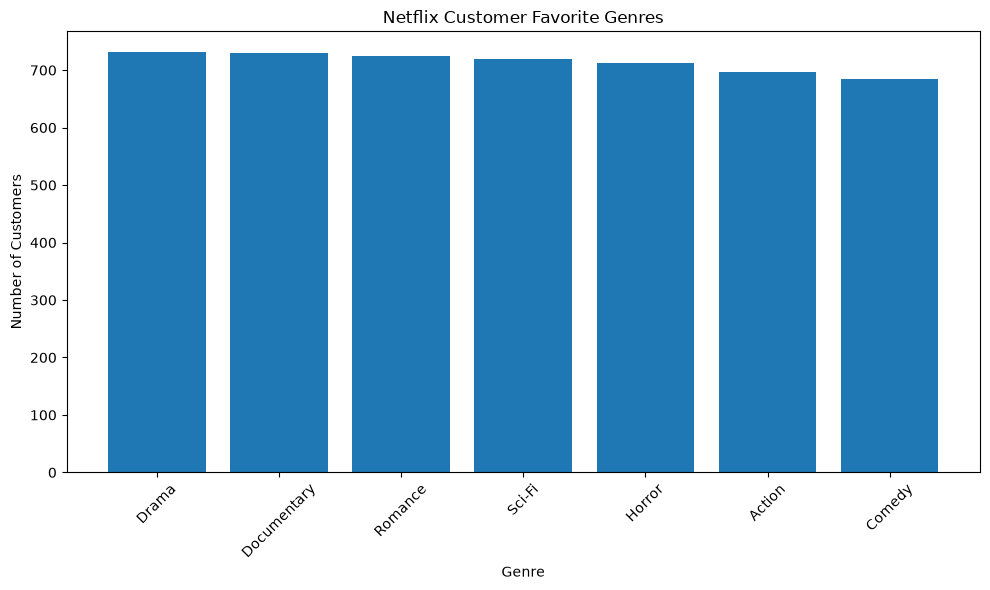

In [209]:
genre_counts = (
    df_clean["favorite_genre"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    genre_counts.index,
    genre_counts.values
)

plt.title("Netflix Customer Favorite Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

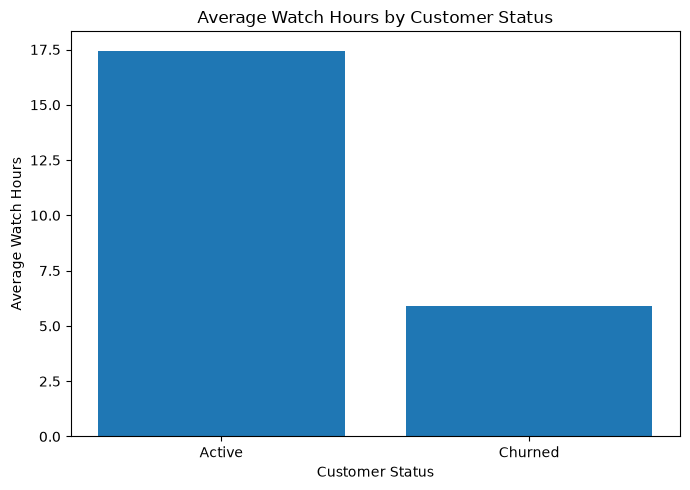

In [210]:
watch_churn = (
    df_clean.groupby("churn_status")["watch_hours"]
    .mean()
)

plt.figure(figsize=(7, 5))

plt.bar(
    watch_churn.index,
    watch_churn.values
)

plt.title("Average Watch Hours by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Watch Hours")

plt.tight_layout()
plt.show()

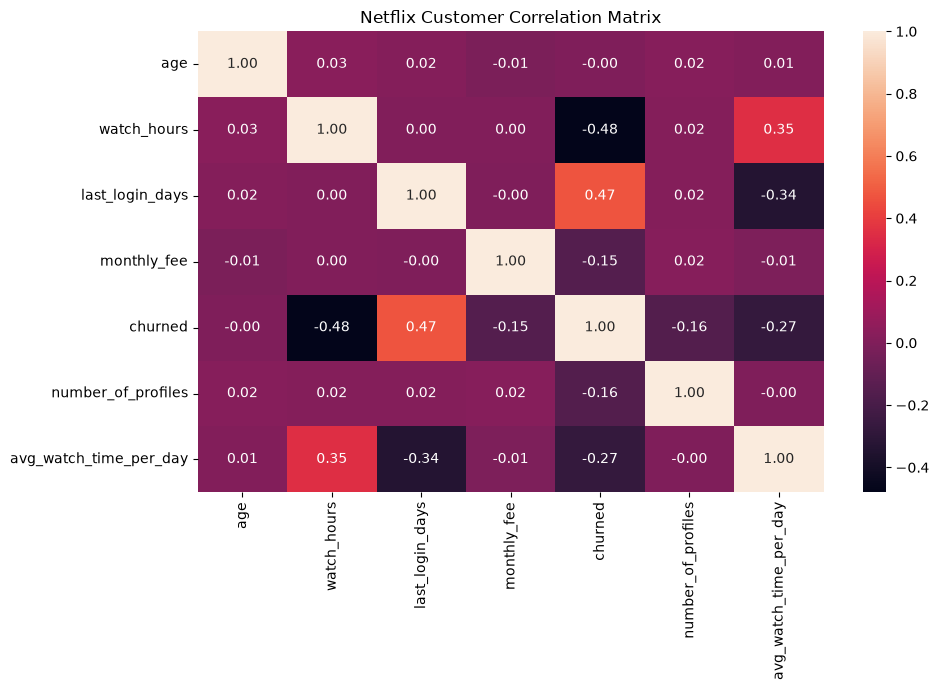

In [211]:
numeric_columns = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "churned",
    "number_of_profiles",
    "avg_watch_time_per_day"
]

correlation_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Netflix Customer Correlation Matrix")

plt.tight_layout()
plt.show()

In [212]:
total_customers = len(df_clean)

churned_customers = df_clean["churned"].sum()

active_customers = total_customers - churned_customers

churn_rate = (
    churned_customers / total_customers
) * 100

total_monthly_revenue = df_clean["monthly_fee"].sum()

annual_revenue = total_monthly_revenue * 12

monthly_revenue_at_risk = (
    df_clean.loc[df_clean["churned"] == 1, "monthly_fee"].sum()
)

annual_revenue_at_risk = monthly_revenue_at_risk * 12

report = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Active Customers",
        "Churned Customers",
        "Overall Churn Rate",
        "Total Monthly Revenue",
        "Estimated Annual Revenue",
        "Monthly Revenue at Risk",
        "Annualized Revenue at Risk"
    ],
    "Value": [
        total_customers,
        active_customers,
        churned_customers,
        round(churn_rate, 2),
        round(total_monthly_revenue, 2),
        round(annual_revenue, 2),
        round(monthly_revenue_at_risk, 2),
        round(annual_revenue_at_risk, 2)
    ]
})

report

,Metric,Value
0,Total Customers,5000.00
1,Active Customers,2485.00
2,Churned Customers,2515.00
3,Overall Churn Rate,50.30
4,Total Monthly Revenue,68417.00
5,Estimated Annual Revenue,821004.00
6,Monthly Revenue at Risk,33009.85
7,Annualized Revenue at Risk,396118.20


In [213]:
print("========== NETFLIX CHURN ANALYSIS ==========\n")

print("Total Customers:", total_customers)

print("Churned Customers:", churned_customers)

print("Overall Churn Rate:", round(churn_rate, 2), "%")

print(
    "Monthly Revenue:",
    round(total_monthly_revenue, 2)
)

print(
    "Annualized Revenue:",
    round(annual_revenue, 2)
)

print(
    "Annualized Revenue at Risk:",
    round(annual_revenue_at_risk, 2)
)

print("\nHighest Churn Subscription:")
print(subscription_churn.index[0], "-", round(subscription_churn.iloc[0], 2), "%")

print("\nHighest Churn Region:")
print(region_churn.index[0], "-", round(region_churn.iloc[0], 2), "%")

print("\nHighest Churn Device:")
print(device_churn.index[0], "-", round(device_churn.iloc[0], 2), "%")

print("\nHighest Churn Activity Level:")
print(activity_churn.index[0], "-", round(activity_churn.iloc[0], 2), "%")

========== NETFLIX CHURN ANALYSIS ==========

Total Customers: 5000
Churned Customers: 2515
Overall Churn Rate: 50.3 %
Monthly Revenue: 68417.0
Annualized Revenue: 821004.0
Annualized Revenue at Risk: 396118.2

Highest Churn Subscription:
Basic - 61.83 %

Highest Churn Region:
Europe - 51.67 %

Highest Churn Device:
Laptop - 51.79 %

Highest Churn Activity Level:
Low - 83.95 %
